Raw shape: (9480, 24)

Columns:
['air_temp', 'albedo', 'azimuth', 'cloud_opacity', 'dewpoint_temp', 'dhi', 'dni', 'ghi', 'gti', 'precipitable_water', 'precipitation_rate', 'relative_humidity', 'surface_pressure', 'snow_depth', 'snow_water_equivalent', 'snow_soiling_rooftop', 'snow_soiling_ground', 'wind_direction_100m', 'wind_direction_10m', 'wind_speed_100m', 'wind_speed_10m', 'zenith', 'period_end', 'period']

Missing values per column:
air_temp                 0
albedo                   0
period_end               0
zenith                   0
wind_speed_10m           0
wind_speed_100m          0
wind_direction_10m       0
wind_direction_100m      0
snow_soiling_ground      0
snow_soiling_rooftop     0
snow_water_equivalent    0
snow_depth               0
surface_pressure         0
relative_humidity        0
precipitation_rate       0
precipitable_water       0
gti                      0
ghi                      0
dni                      0
dhi                      0
dewpoint_temp    

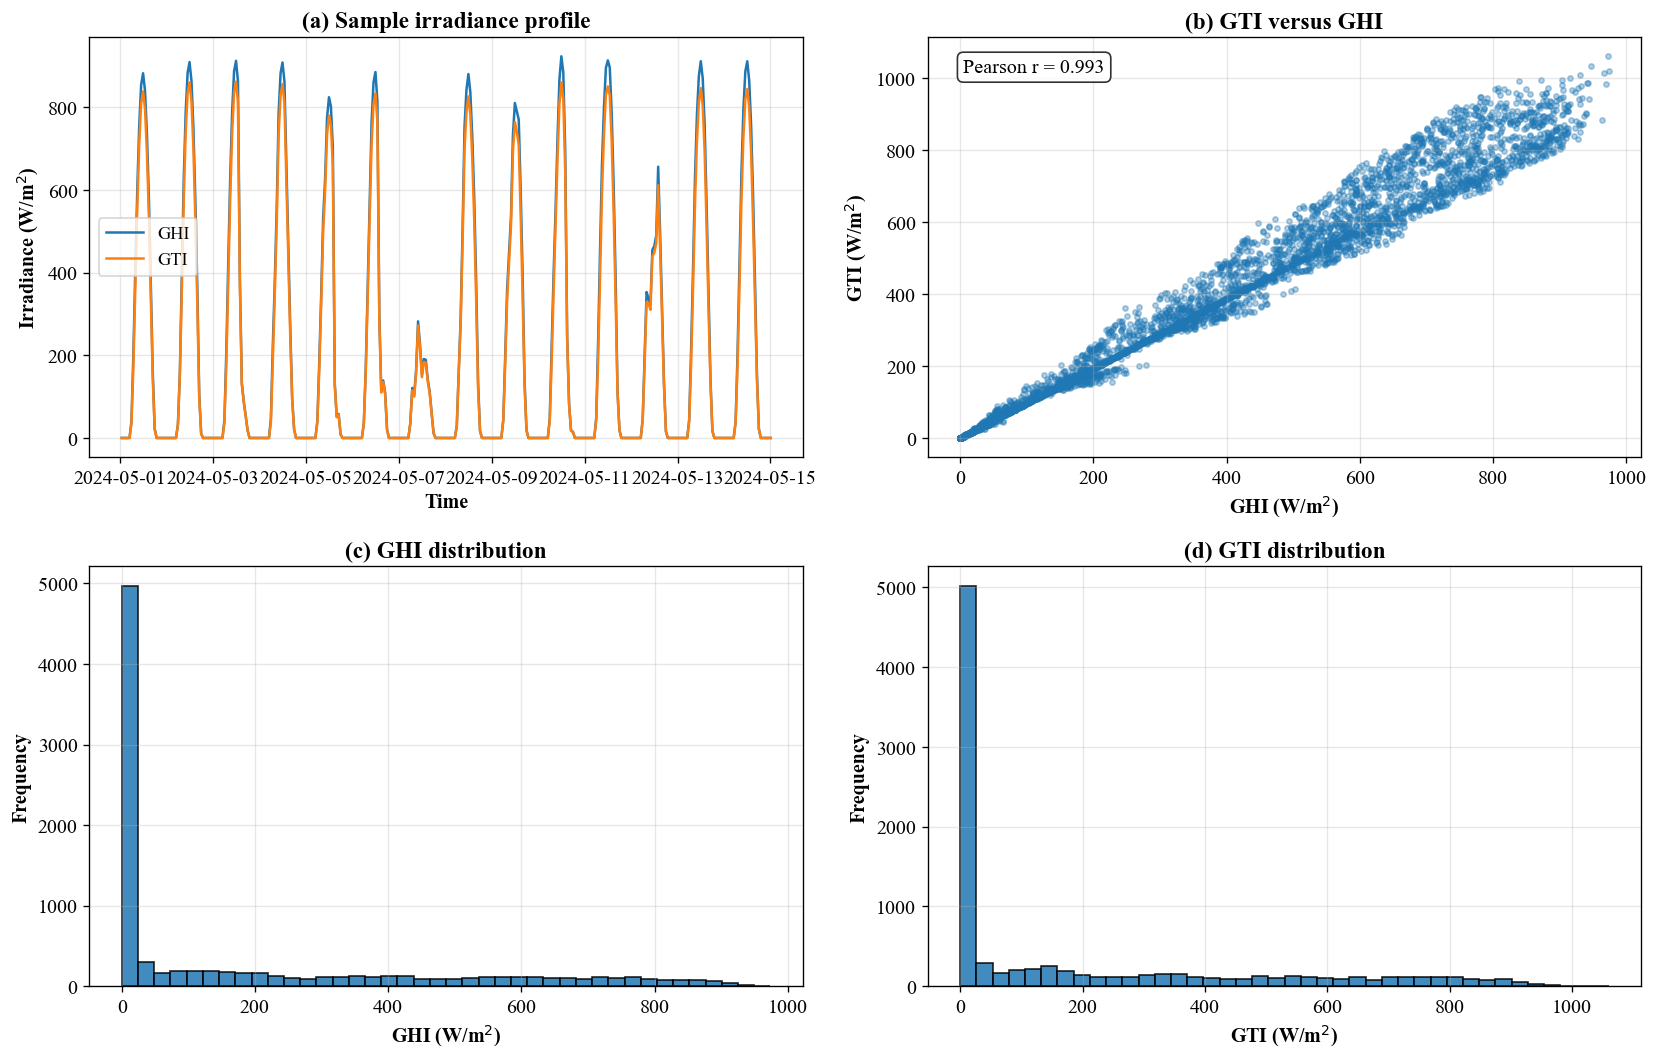

In [2]:
import os
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- IEEE-style plotting ----------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif", "Nimbus Roman No9 L"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300
})

# ---------------- Load data ----------------
df = pd.read_csv('12.csv', encoding='ascii')

print("Raw shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

# ---------------- Parse time ----------------
# period_end appears timezone-aware in the CSV
df["period_end"] = pd.to_datetime(df["period_end"], errors="coerce")
df = df.sort_values("period_end").reset_index(drop=True)

# Create a simple time index if needed later
df["date"] = df["period_end"].dt.date
df["hour"] = df["period_end"].dt.hour

print("\nParsed time range:")
print("Start:", df["period_end"].min())
print("End  :", df["period_end"].max())

print("\nData types:")
print(df.dtypes)

# ---------------- Basic sanity checks ----------------
irradiance_cols = ["ghi", "gti", "dni", "dhi"]
for col in irradiance_cols:
    if col in df.columns:
        print(f"\n{col.upper()} summary:")
        print(df[col].describe())

# ---------------- Figure S-1-1: Data overview ----------------
# Unique, compact, publication-style overview with time series + relationship + distributions
sample_len = min(336, len(df))  # first 14 days if hourly data
sample_df = df.iloc[:sample_len].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Time series of GHI and GTI
ax = axes[0, 0]
ax.plot(sample_df["period_end"], sample_df["ghi"], label="GHI", linewidth=1.5)
ax.plot(sample_df["period_end"], sample_df["gti"], label="GTI", linewidth=1.5)
ax.set_title("(a) Sample irradiance profile",fontsize=14, fontweight='bold')
ax.set_xlabel("Time",fontsize=12, fontweight='bold')
ax.set_ylabel("Irradiance (W/m$^2$)",fontsize=12, fontweight='bold')
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

# (b) Scatter: GHI vs GTI
ax = axes[0, 1]
ax.scatter(df["ghi"], df["gti"], s=10, alpha=0.35)
ax.set_title("(b) GTI versus GHI",fontsize=14, fontweight='bold')
ax.set_xlabel("GHI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.set_ylabel("GTI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add correlation annotation
valid_pair = df[["ghi", "gti"]].dropna()
if len(valid_pair) > 1:
    corr = valid_pair["ghi"].corr(valid_pair["gti"])
    ax.text(
        0.05, 0.95,
        f"Pearson r = {corr:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

# (c) Distribution of GHI
ax = axes[1, 0]
ax.hist(df["ghi"].dropna(), bins=40, alpha=0.85, edgecolor="black")
ax.set_title("(c) GHI distribution",fontsize=14, fontweight='bold')
ax.set_xlabel("GHI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency",fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# (d) Distribution of GTI
ax = axes[1, 1]
ax.hist(df["gti"].dropna(), bins=40, alpha=0.85, edgecolor="black")
ax.set_title("(d) GTI distribution",fontsize=14, fontweight='bold')
ax.set_xlabel("GTI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency",fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Feature dataset shape: (9476, 50)


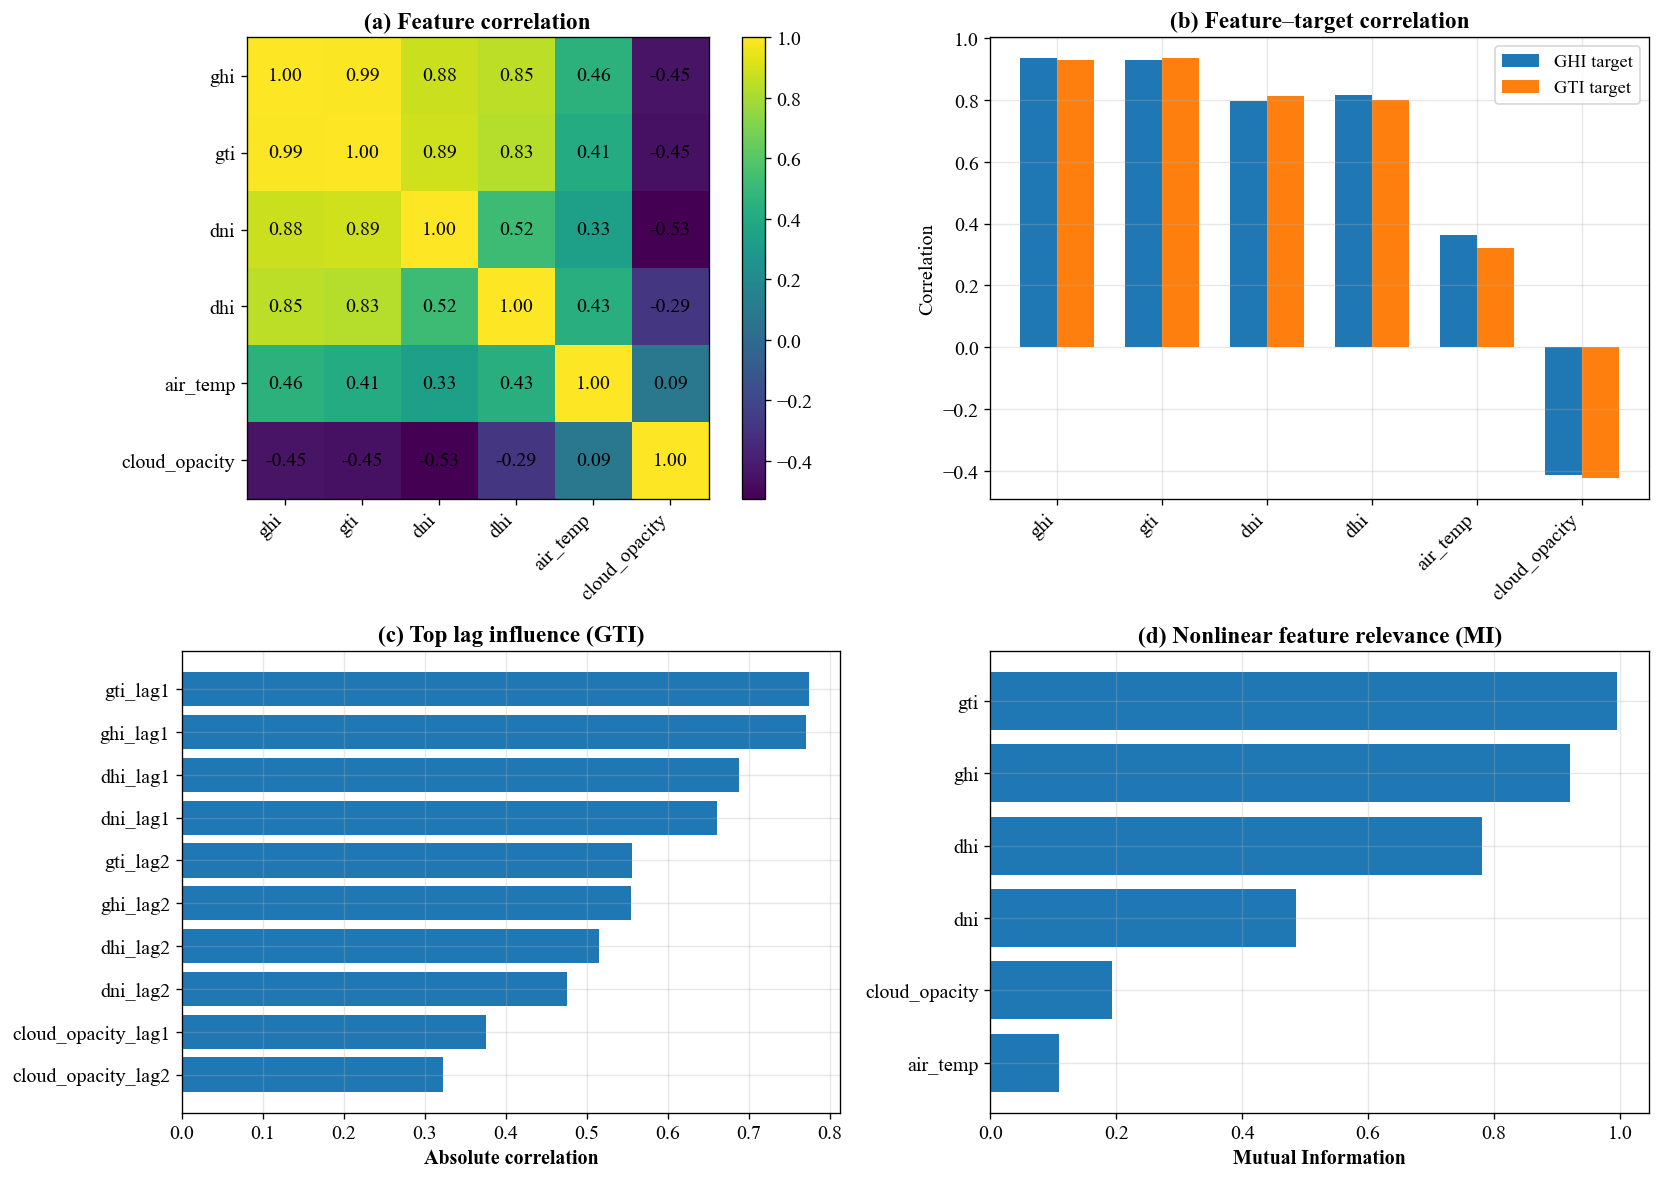

In [3]:
import os
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# ---------------- Reproducibility ----------------
np.random.seed(42)

# ---------------- IEEE-style plotting ----------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "savefig.dpi": 300
})

# ---------------- Paths ----------------
DATA_PATH = "12.csv"
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- Load data ----------------
df = pd.read_csv(DATA_PATH)
df["period_end"] = pd.to_datetime(df["period_end"], errors="coerce")
df = df.sort_values("period_end").reset_index(drop=True)

# ---------------- Feature Engineering ----------------
df_feat = df.copy()

# Time features
df_feat["hour"] = df_feat["period_end"].dt.hour
df_feat["dayofyear"] = df_feat["period_end"].dt.dayofyear

df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)
df_feat["doy_sin"] = np.sin(2 * np.pi * df_feat["dayofyear"] / 365)
df_feat["doy_cos"] = np.cos(2 * np.pi * df_feat["dayofyear"] / 365)

# Lag features
lag_features: List[str] = ["ghi", "gti", "dni", "dhi", "air_temp", "cloud_opacity"]

for col in lag_features:
    if col in df_feat.columns:
        for lag in [1, 2, 3]:
            df_feat[f"{col}_lag{lag}"] = df_feat[col].shift(lag)

# Targets
df_feat["target_ghi"] = df_feat["ghi"].shift(-1)
df_feat["target_gti"] = df_feat["gti"].shift(-1)

# Drop NaNs
df_feat = df_feat.dropna().reset_index(drop=True)

print("Feature dataset shape:", df_feat.shape)

# ---------------- Column selection ----------------
base_cols = ["ghi", "gti", "dni", "dhi", "air_temp", "cloud_opacity"]
base_cols = [c for c in base_cols if c in df_feat.columns]

# ---------------- (a) Correlation ----------------
corr_matrix = df_feat[base_cols].corr()

# ---------------- (b) Feature–target correlation ----------------
target_corr_ghi = df_feat[base_cols].corrwith(df_feat["target_ghi"])
target_corr_gti = df_feat[base_cols].corrwith(df_feat["target_gti"])

# ---------------- (c) Lag importance ----------------
lag_cols = [c for c in df_feat.columns if "lag" in c]

lag_importance_gti = (
    df_feat[lag_cols]
    .corrwith(df_feat["target_gti"])
    .abs()
    .sort_values(ascending=False)
)

# ---------------- (d) Mutual Information ----------------
X_mi = df_feat[base_cols]
y_mi = df_feat["target_gti"]

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=base_cols).sort_values()

# ---------------- Plot ----------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Correlation heatmap
ax = axes[0, 0]
im = ax.imshow(corr_matrix)
ax.set_title("(a) Feature correlation",fontsize=14, fontweight='bold')
ax.set_xticks(range(len(base_cols)))
ax.set_yticks(range(len(base_cols)))
ax.set_xticklabels(base_cols, rotation=45, ha="right")
ax.set_yticklabels(base_cols)

for i in range(len(base_cols)):
    for j in range(len(base_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

fig.colorbar(im, ax=ax)

# (b) Feature vs target correlation
ax = axes[0, 1]
x = np.arange(len(base_cols))
width = 0.35

ax.bar(x - width/2, target_corr_ghi, width, label="GHI target")
ax.bar(x + width/2, target_corr_gti, width, label="GTI target")

ax.set_xticks(x)
ax.set_xticklabels(base_cols, rotation=45, ha="right")
ax.set_title("(b) Feature–target correlation",fontsize=14, fontweight='bold')
ax.set_ylabel("Correlation")
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Lag importance
ax = axes[1, 0]
top_lags = lag_importance_gti.head(10)

ax.barh(top_lags.index, top_lags.values)
ax.set_title("(c) Top lag influence (GTI)",fontsize=14, fontweight='bold')
ax.set_xlabel("Absolute correlation",fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# (d) Mutual information
ax = axes[1, 1]
ax.barh(mi_series.index, mi_series.values)
ax.set_title("(d) Nonlinear feature relevance (MI)",fontsize=14, fontweight='bold')
ax.set_xlabel("Mutual Information",fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Train size: (7580, 27)
Test size : (1896, 27)

GHI Model Performance:
R²   : 0.9820
RMSE : 41.2444
MAE  : 18.4645

GTI Model Performance:
R²   : 0.9828
RMSE : 39.5529
MAE  : 18.4733


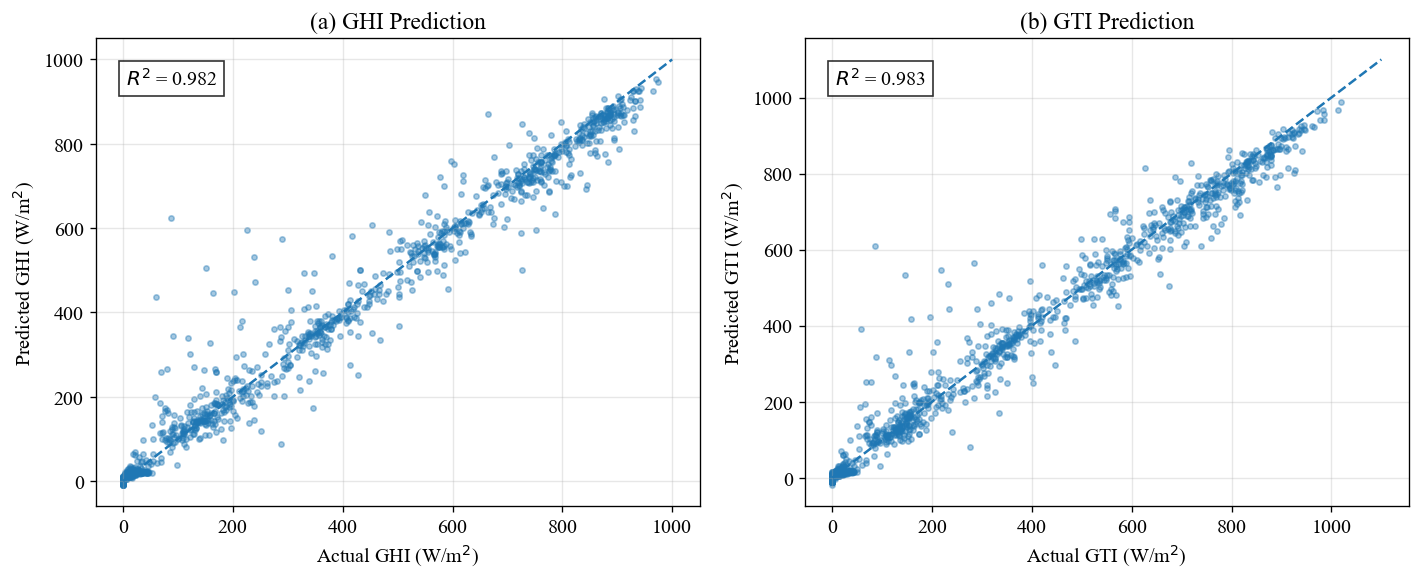

In [8]:
import os
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ---------------- Reproducibility ----------------
np.random.seed(42)

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Time-based split ----------------
split_idx = int(0.8 * len(X))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_ghi_train, y_ghi_test = y_ghi.iloc[:split_idx], y_ghi.iloc[split_idx:]
y_gti_train, y_gti_test = y_gti.iloc[:split_idx], y_gti.iloc[split_idx:]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

# ---------------- Model Definition ----------------
def train_catboost() -> CatBoostRegressor:
    return CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0,
        random_seed=42
    )

# ---------------- Train Models ----------------
model_ghi = train_catboost()
model_gti = train_catboost()

model_ghi.fit(X_train, y_ghi_train)
model_gti.fit(X_train, y_gti_train)

# ---------------- Predictions ----------------
y_pred_ghi = model_ghi.predict(X_test)
y_pred_gti = model_gti.predict(X_test)

# ---------------- Metrics ----------------
def evaluate(y_true, y_pred, label: str) -> None:
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{label} Performance:")
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")

evaluate(y_ghi_test, y_pred_ghi, "GHI Model")
evaluate(y_gti_test, y_pred_gti, "GTI Model")

# ---------------- Figure S-2-1: Regression Comparison ----------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- GHI plot ---
ax = axes[0]
ax.scatter(y_ghi_test, y_pred_ghi, s=10, alpha=0.4)
ax.plot([0, 1000], [0, 1000], linestyle="--")
r2_ghi = r2_score(y_ghi_test, y_pred_ghi)

ax.set_title("(a) GHI Prediction")
ax.set_xlabel("Actual GHI (W/m$^2$)")
ax.set_ylabel("Predicted GHI (W/m$^2$)")
ax.text(0.05, 0.9, f"$R^2$ = {r2_ghi:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# --- GTI plot ---
ax = axes[1]
ax.scatter(y_gti_test, y_pred_gti, s=10, alpha=0.4)
ax.plot([0, 1100], [0, 1100], linestyle="--")
r2_gti = r2_score(y_gti_test, y_pred_gti)

ax.set_title("(b) GTI Prediction")
ax.set_xlabel("Actual GTI (W/m$^2$)")
ax.set_ylabel("Predicted GTI (W/m$^2$)")
ax.text(0.05, 0.9, f"$R^2$ = {r2_gti:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------- Save results for next steps ----------------
results_df = pd.DataFrame({
    "actual_ghi": y_ghi_test.values,
    "pred_ghi": y_pred_ghi,
    "actual_gti": y_gti_test.values,
    "pred_gti": y_pred_gti
})

results_df.to_csv(os.path.join(OUTPUT_DIR, "forecast_results.csv"), index=False)

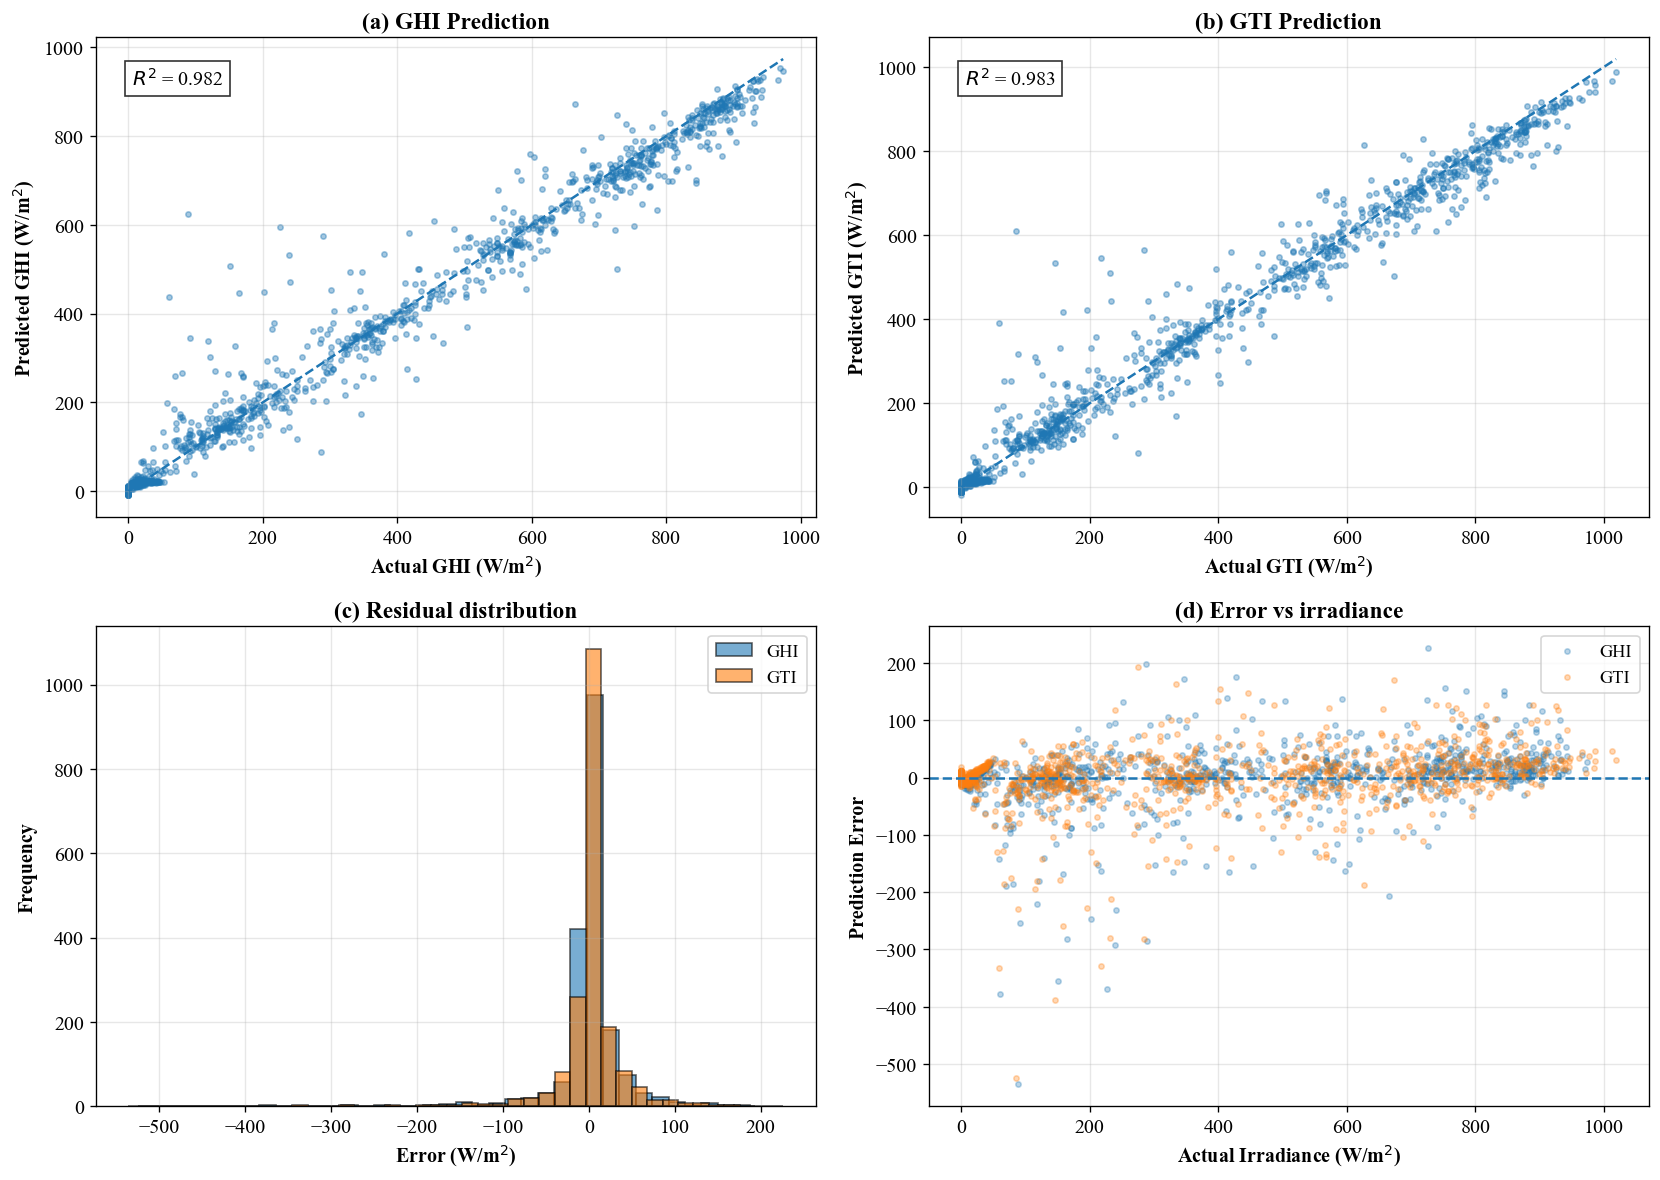

In [7]:
import os
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ---------------- Reproducibility ----------------
np.random.seed(42)

# ---------------- IEEE-style plotting ----------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300
})

# ---------------- Paths ----------------
DATA_PATH = "12.csv"
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- Load data ----------------
df = pd.read_csv(DATA_PATH)
df["period_end"] = pd.to_datetime(df["period_end"], errors="coerce")
df = df.sort_values("period_end").reset_index(drop=True)

# ---------------- Feature Engineering ----------------
df_feat = df.copy()

# Time features
df_feat["hour"] = df_feat["period_end"].dt.hour
df_feat["dayofyear"] = df_feat["period_end"].dt.dayofyear

df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)
df_feat["doy_sin"] = np.sin(2 * np.pi * df_feat["dayofyear"] / 365)
df_feat["doy_cos"] = np.cos(2 * np.pi * df_feat["dayofyear"] / 365)

# Lag features
lag_features: List[str] = ["ghi", "gti", "dni", "dhi", "air_temp", "cloud_opacity"]

for col in lag_features:
    if col in df_feat.columns:
        for lag in [1, 2, 3]:
            df_feat[f"{col}_lag{lag}"] = df_feat[col].shift(lag)

# Targets
df_feat["target_ghi"] = df_feat["ghi"].shift(-1)
df_feat["target_gti"] = df_feat["gti"].shift(-1)

# Drop NaNs
df_feat = df_feat.dropna().reset_index(drop=True)

# ---------------- Feature Selection ----------------
feature_cols = [
    "ghi", "dni", "dhi", "air_temp", "cloud_opacity",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos"
]

for col in lag_features:
    for lag in [1, 2, 3]:
        if f"{col}_lag{lag}" in df_feat.columns:
            feature_cols.append(f"{col}_lag{lag}")

X = df_feat[feature_cols]
y_ghi = df_feat["target_ghi"]
y_gti = df_feat["target_gti"]

# ---------------- Train/Test Split ----------------
split_idx = int(0.8 * len(X))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_ghi_train, y_ghi_test = y_ghi.iloc[:split_idx], y_ghi.iloc[split_idx:]
y_gti_train, y_gti_test = y_gti.iloc[:split_idx], y_gti.iloc[split_idx:]

# ---------------- Model ----------------
def train_model() -> CatBoostRegressor:
    return CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0,
        random_seed=42
    )

model_ghi = train_model()
model_gti = train_model()

model_ghi.fit(X_train, y_ghi_train)
model_gti.fit(X_train, y_gti_train)

# ---------------- Predictions ----------------
y_pred_ghi = model_ghi.predict(X_test)
y_pred_gti = model_gti.predict(X_test)

# ---------------- Metrics ----------------
r2_ghi = r2_score(y_ghi_test, y_pred_ghi)
r2_gti = r2_score(y_gti_test, y_pred_gti)

# ---------------- Residuals ----------------
residual_ghi = y_ghi_test.values - y_pred_ghi
residual_gti = y_gti_test.values - y_pred_gti

# ---------------- Figure ----------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) GHI Regression
ax = axes[0, 0]
ax.scatter(y_ghi_test, y_pred_ghi, s=10, alpha=0.4)
lims = [0, max(y_ghi_test.max(), y_pred_ghi.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title("(a) GHI Prediction",fontsize=14, fontweight='bold')
ax.set_xlabel("Actual GHI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted GHI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.text(0.05, 0.9, f"$R^2$ = {r2_ghi:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# (b) GTI Regression
ax = axes[0, 1]
ax.scatter(y_gti_test, y_pred_gti, s=10, alpha=0.4)
lims = [0, max(y_gti_test.max(), y_pred_gti.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title("(b) GTI Prediction",fontsize=14, fontweight='bold')
ax.set_xlabel("Actual GTI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted GTI (W/m$^2$)",fontsize=12, fontweight='bold')
ax.text(0.05, 0.9, f"$R^2$ = {r2_gti:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# (c) Residual Distribution
ax = axes[1, 0]
ax.hist(residual_ghi, bins=40, alpha=0.6, label="GHI", edgecolor="black")
ax.hist(residual_gti, bins=40, alpha=0.6, label="GTI", edgecolor="black")
ax.set_title("(c) Residual distribution",fontsize=14, fontweight='bold')
ax.set_xlabel("Error (W/m$^2$)",fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# (d) Error vs Irradiance
ax = axes[1, 1]
ax.scatter(y_ghi_test, residual_ghi, s=10, alpha=0.3, label="GHI")
ax.scatter(y_gti_test, residual_gti, s=10, alpha=0.3, label="GTI")
ax.axhline(0, linestyle="--")
ax.set_title("(d) Error vs irradiance",fontsize=14, fontweight='bold')
ax.set_xlabel("Actual Irradiance (W/m$^2$)",fontsize=12, fontweight='bold')
ax.set_ylabel("Prediction Error",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


GTI-based PV PV Performance:
R²   : 0.9827
RMSE : 0.0387
MAE  : 0.0181

GHI-based PV PV Performance:
R²   : 0.9780
RMSE : 0.0436
MAE  : 0.0215


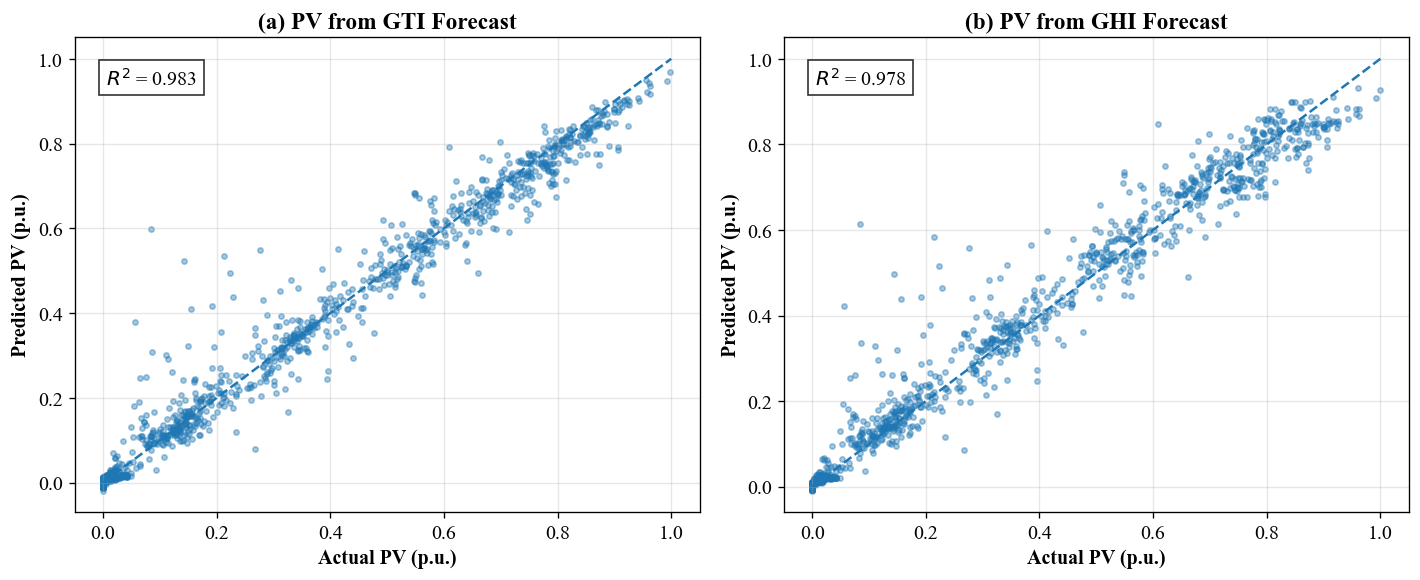

In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Constants ----------------
P_RATED = 1.0  # normalized (kW per kW installed)
G_REF = 1000.0
TEMP_COEFF = 0.004

# ---------------- Load results ----------------
results_df = pd.read_csv(os.path.join(OUTPUT_DIR, "forecast_results.csv"))

# Align temperature (test portion)
temp_test = X_test["air_temp"].values

# ---------------- Temperature correction ----------------
def temp_efficiency(temp: np.ndarray) -> np.ndarray:
    return 1 - TEMP_COEFF * (temp - 25)

eta_temp = temp_efficiency(temp_test)

# ---------------- PV Power Computation ----------------
# Ground truth (using actual GTI)
pv_actual = P_RATED * (results_df["actual_gti"].values / G_REF) * eta_temp

# GTI forecast-based PV
pv_pred_gti = P_RATED * (results_df["pred_gti"].values / G_REF) * eta_temp

# GHI-based proxy PV (IMPORTANT: this is the weaker approximation)
pv_pred_ghi = P_RATED * (results_df["pred_ghi"].values / G_REF) * eta_temp

# ---------------- Metrics ----------------
def evaluate_power(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    
    print(f"\n{label} PV Performance:")
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")

evaluate_power(pv_actual, pv_pred_gti, "GTI-based PV")
evaluate_power(pv_actual, pv_pred_ghi, "GHI-based PV")

# ---------------- Figure S-2-2: PV Comparison ----------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- GTI PV ---
ax = axes[0]
ax.scatter(pv_actual, pv_pred_gti, s=10, alpha=0.4)
ax.plot([0, 1], [0, 1], linestyle="--")
r2_gti = r2_score(pv_actual, pv_pred_gti)

ax.set_title("(a) PV from GTI Forecast",fontsize=14, fontweight='bold')
ax.set_xlabel("Actual PV (p.u.)",fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted PV (p.u.)",fontsize=12, fontweight='bold')
ax.text(0.05, 0.9, f"$R^2$ = {r2_gti:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

# --- GHI PV ---
ax = axes[1]
ax.scatter(pv_actual, pv_pred_ghi, s=10, alpha=0.4)
ax.plot([0, 1], [0, 1], linestyle="--")
r2_ghi = r2_score(pv_actual, pv_pred_ghi)

ax.set_title("(b) PV from GHI Forecast",fontsize=14, fontweight='bold')
ax.set_xlabel("Actual PV (p.u.)",fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted PV (p.u.)",fontsize=12, fontweight='bold')
ax.text(0.05, 0.9, f"$R^2$ = {r2_ghi:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------- Save PV results ----------------
pv_df = pd.DataFrame({
    "pv_actual": pv_actual,
    "pv_pred_gti": pv_pred_gti,
    "pv_pred_ghi": pv_pred_ghi
})

pv_df.to_csv(os.path.join(OUTPUT_DIR, "pv_results.csv"), index=False)

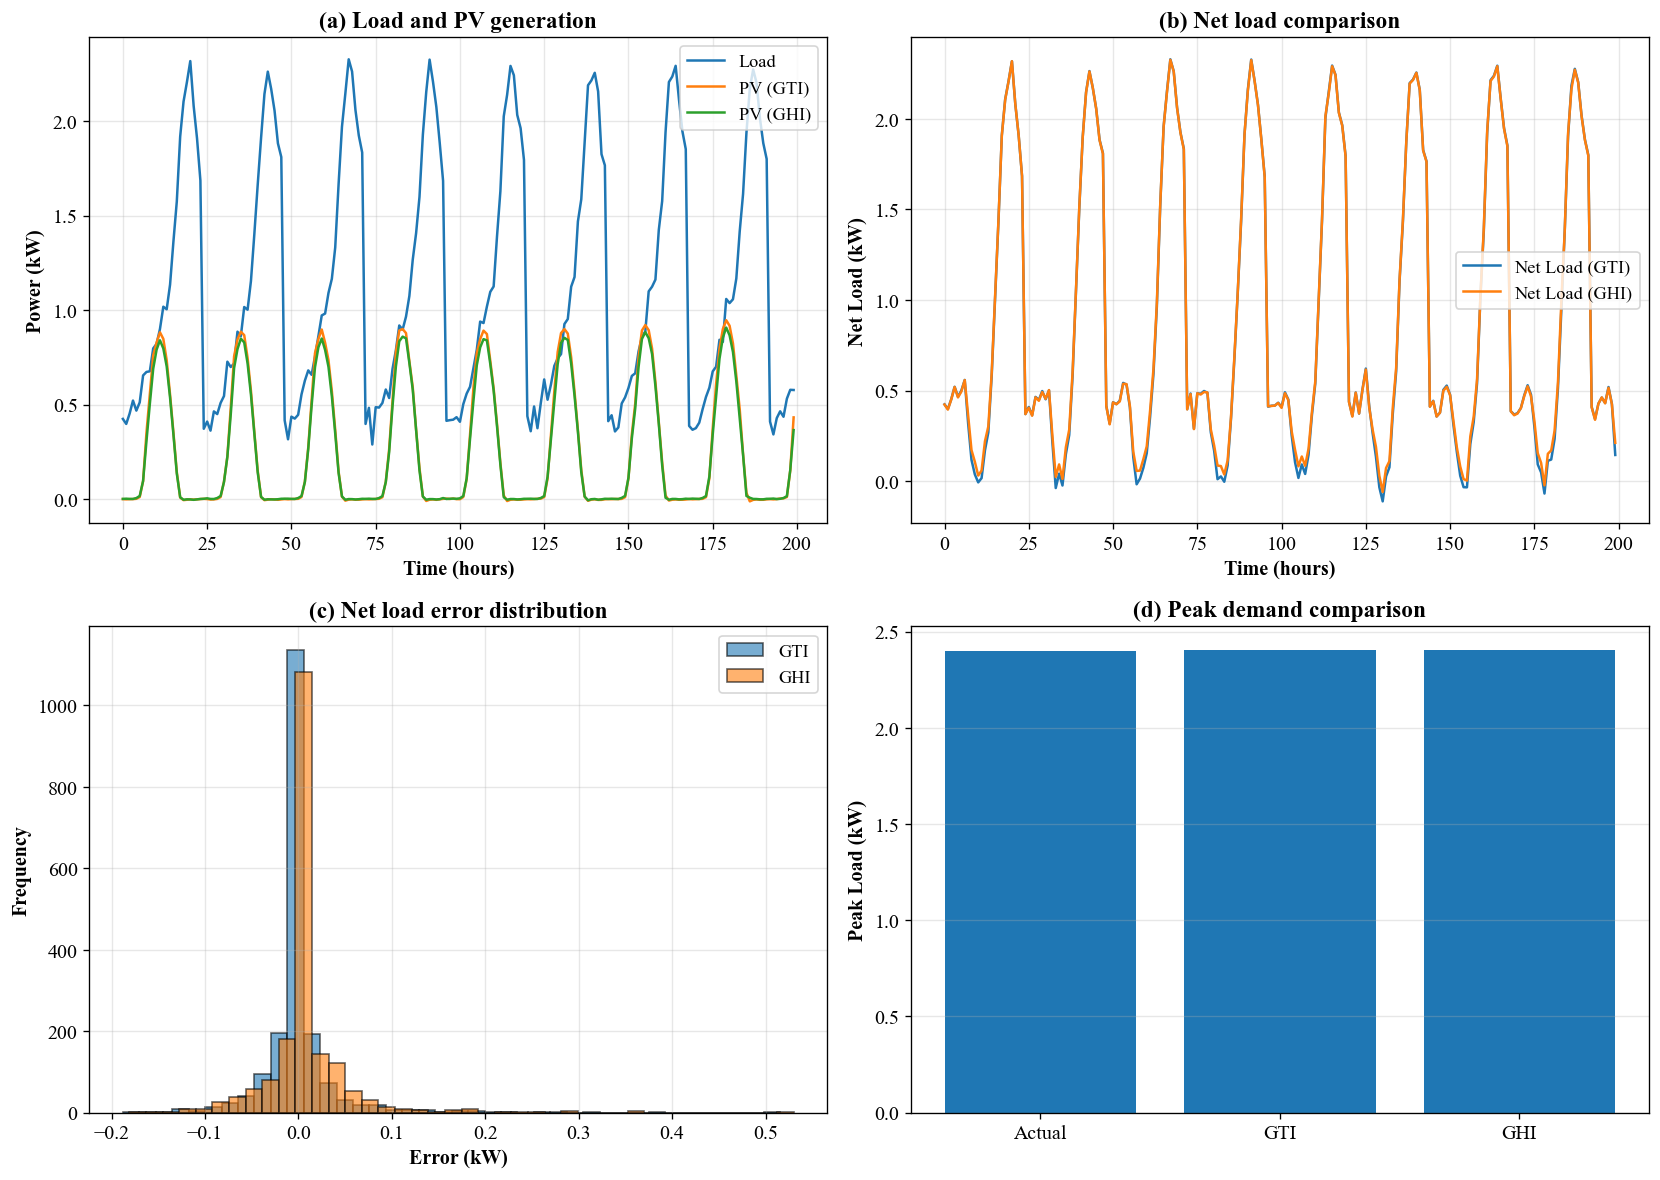

In [45]:
# ---------------- Additional Metrics ----------------
net_load_actual = load - pv_df["pv_actual"].values
net_load_gti = load - pv_df["pv_pred_gti"].values
net_load_ghi = load - pv_df["pv_pred_ghi"].values

# Net load error
error_gti = net_load_actual - net_load_gti
error_ghi = net_load_actual - net_load_ghi

# Peak demand
peak_actual = np.max(net_load_actual)
peak_gti = np.max(net_load_gti)
peak_ghi = np.max(net_load_ghi)

# ---------------- Figure ----------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sample = 200

# (a) Load vs PV
ax = axes[0, 0]
ax.plot(load[:sample], label="Load")
ax.plot(pv_df["pv_pred_gti"].values[:sample], label="PV (GTI)")
ax.plot(pv_df["pv_pred_ghi"].values[:sample], label="PV (GHI)")
ax.set_title("(a) Load and PV generation",fontsize=14, fontweight='bold')
ax.set_xlabel("Time (hours)",fontsize=12, fontweight='bold')
ax.set_ylabel("Power (kW)",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Net load comparison (KEY PANEL)
ax = axes[0, 1]
ax.plot(net_load_gti[:sample], label="Net Load (GTI)")
ax.plot(net_load_ghi[:sample], label="Net Load (GHI)")
ax.set_title("(b) Net load comparison",fontsize=14, fontweight='bold')
ax.set_xlabel("Time (hours)",fontsize=12, fontweight='bold')
ax.set_ylabel("Net Load (kW)",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Net load error distribution
ax = axes[1, 0]
ax.hist(error_gti, bins=40, alpha=0.6, label="GTI", edgecolor="black")
ax.hist(error_ghi, bins=40, alpha=0.6, label="GHI", edgecolor="black")
ax.set_title("(c) Net load error distribution",fontsize=14, fontweight='bold')
ax.set_xlabel("Error (kW)",fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# (d) Peak demand comparison
ax = axes[1, 1]
labels = ["Actual", "GTI", "GHI"]
values = [peak_actual, peak_gti, peak_ghi]

ax.bar(labels, values)
ax.set_title("(d) Peak demand comparison",fontsize=14, fontweight='bold')
ax.set_ylabel("Peak Load (kW)", fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
import numpy as np
import os

# ---------------- Constants ----------------
TILT = 20  # degrees
G_REF = 1000.0
P_RATED = 1.0
TEMP_COEFF = 0.004

# ---------------- Extract aligned zenith ----------------
# IMPORTANT: use same split index
zenith_test = df_feat["zenith"].iloc[split_idx:].values
temp_test = df_feat["air_temp"].iloc[split_idx:].values

# ---------------- Temperature efficiency ----------------
def temp_efficiency(temp):
    return 1 - TEMP_COEFF * (temp - 25)

eta_temp = temp_efficiency(temp_test)

# ---------------- Transposition ----------------
theta_z = np.radians(zenith_test)
beta = np.radians(TILT)

cos_term = np.cos(theta_z - beta)
cos_term = np.clip(cos_term, 0, None)

# ---------------- Convert GHI → GTI ----------------
gti_from_ghi = results_df["pred_ghi"].values * cos_term

# ---------------- PV recomputation ----------------
pv_pred_ghi_corrected = (
    P_RATED * (gti_from_ghi / G_REF) * eta_temp
)

# ---------------- Update dataframe ----------------
pv_df["pv_pred_ghi_corrected"] = pv_pred_ghi_corrected

pv_df.to_csv(os.path.join(OUTPUT_DIR, "pv_results.csv"), index=False)

print("Corrected GHI→GTI conversion applied successfully.")

Corrected GHI→GTI conversion applied successfully.


In [49]:
pv_ghi = pv_df["pv_pred_ghi_corrected"].values

In [50]:
pv_ghi

array([ 0.,  0.,  0., ..., -0., -0., -0.])

In [53]:
import os
import numpy as np
import pandas as pd

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Load data ----------------
pv_df = pd.read_csv(os.path.join(OUTPUT_DIR, "pv_results.csv"))
load_df = pd.read_csv(os.path.join(OUTPUT_DIR, "load_results.csv"))

load = load_df["load"].values
pv_gti = pv_df["pv_pred_gti"].values
pv_ghi = pv_df["pv_pred_ghi_corrected"].values  # corrected version

# ---------------- Metric function ----------------
def compute_metrics(pv, load):
    pv_used = np.minimum(pv, load)
    
    pv_util = np.sum(pv_used) / np.sum(pv)
    ssr = np.sum(pv_used) / np.sum(load)
    
    grid_import = np.sum(np.maximum(load - pv, 0))
    excess_pv = np.sum(np.maximum(pv - load, 0))
    
    net_load = load - pv
    net_std = np.std(net_load)
    
    return {
        "PV Utilization": pv_util,
        "Self-Sufficiency Ratio": ssr,
        "Grid Import (kWh)": grid_import,
        "Excess PV (kWh)": excess_pv,
        "Net Load Std Dev": net_std
    }

# ---------------- Compute ----------------
metrics_gti = compute_metrics(pv_gti, load)
metrics_ghi = compute_metrics(pv_ghi, load)

# ---------------- Convert to table ----------------
metrics_df = pd.DataFrame({
    "Metric": list(metrics_gti.keys()),
    "GTI-Based": list(metrics_gti.values()),
    "GHI-Based": list(metrics_ghi.values())
})

# ---------------- Round for paper ----------------
metrics_df["GTI-Based"] = metrics_df["GTI-Based"].round(4)
metrics_df["GHI-Based"] = metrics_df["GHI-Based"].round(4)

print("\nCorrected Operational Metrics Table:\n")
print(metrics_df.to_string(index=False))

# ---------------- Save ----------------
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "S-3-Table.csv"), index=False)


Corrected Operational Metrics Table:

                Metric  GTI-Based  GHI-Based
        PV Utilization     0.9981     0.9990
Self-Sufficiency Ratio     0.1850     0.1728
     Grid Import (kWh)  1792.4059  1819.3048
       Excess PV (kWh)     0.7799     0.3829
      Net Load Std Dev     0.7759     0.7651


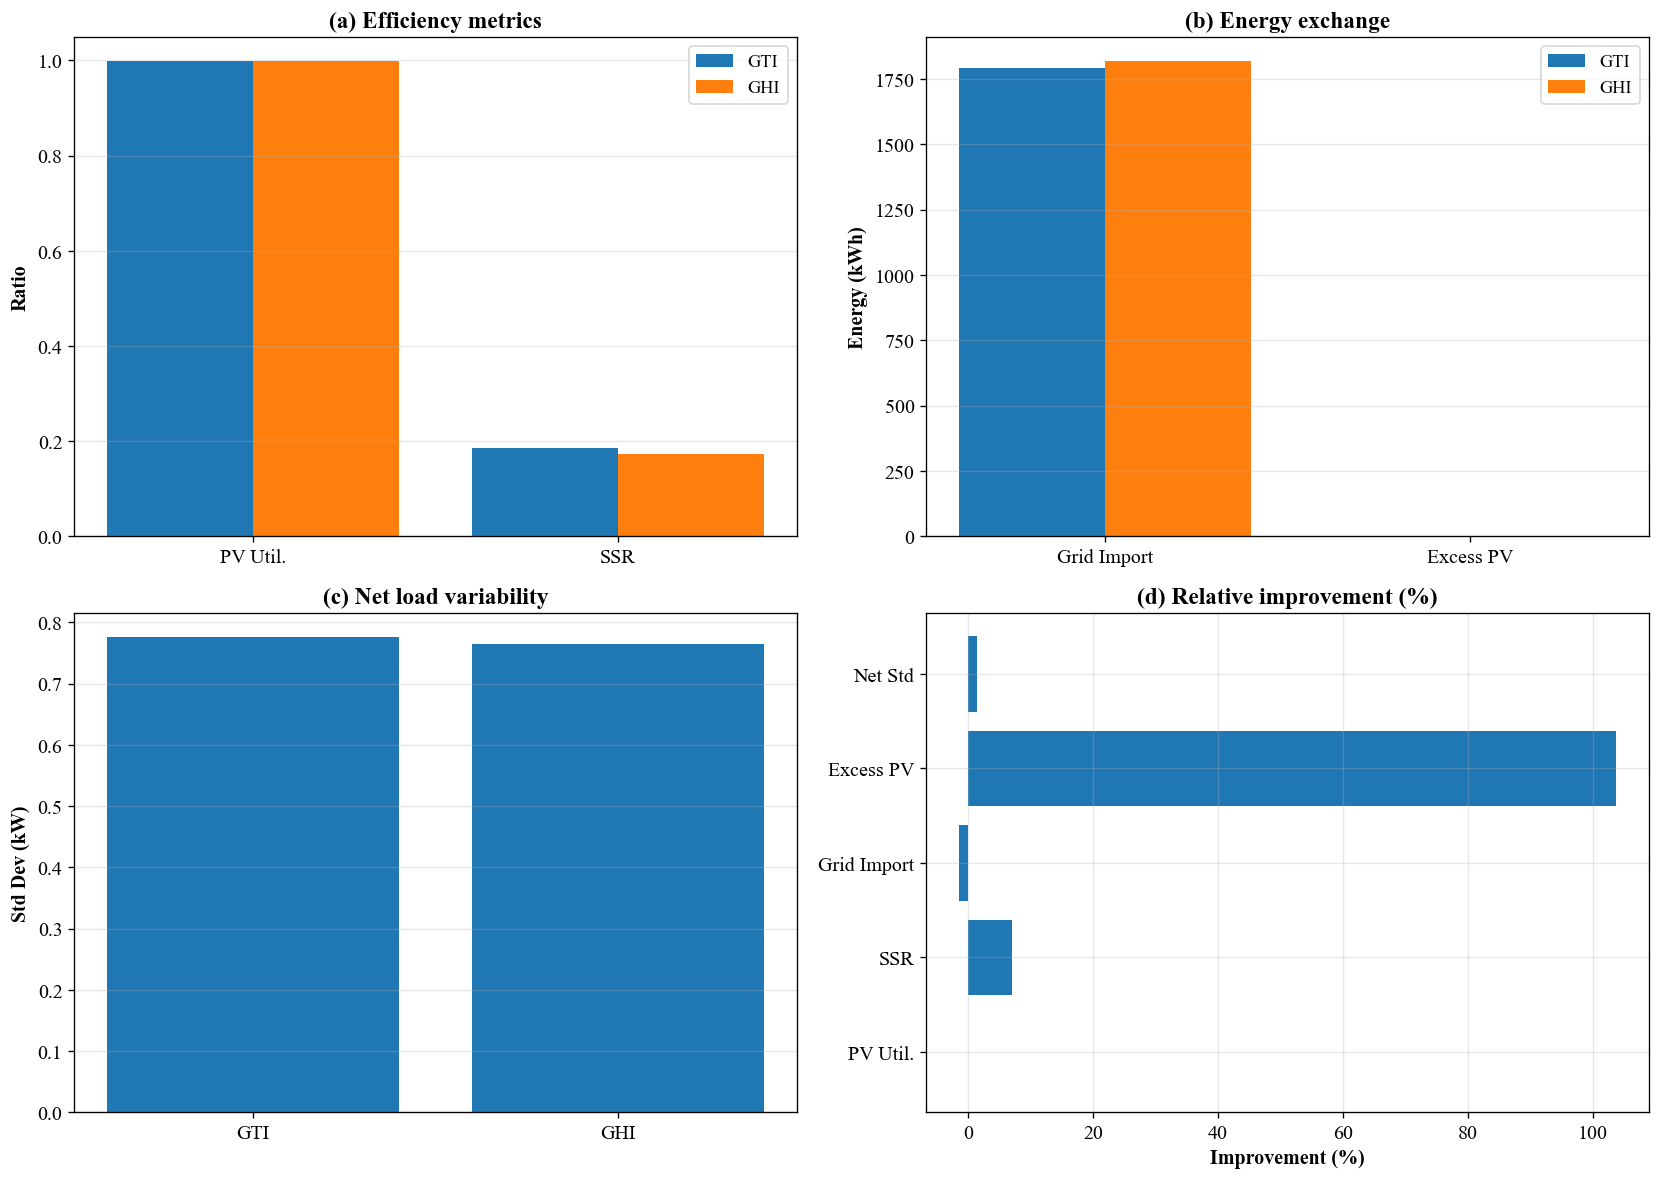

In [56]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Data ----------------
metrics = ["PV Util.", "SSR", "Grid Import", "Excess PV", "Net Std"]

gti_vals = np.array([0.9981, 0.1850, 1792.4059, 0.7799, 0.7759])
ghi_vals = np.array([0.9990, 0.1728, 1819.3048, 0.3829, 0.7651])

# Improvement (%)
improvement = (gti_vals - ghi_vals) / (ghi_vals + 1e-8) * 100

# ---------------- Figure ----------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Efficiency metrics
ax = axes[0, 0]
idx = [0, 1]
x = np.arange(len(idx))

ax.bar(x - 0.2, gti_vals[idx], 0.4, label="GTI")
ax.bar(x + 0.2, ghi_vals[idx], 0.4, label="GHI")

ax.set_xticks(x)
ax.set_xticklabels([metrics[i] for i in idx])
ax.set_title("(a) Efficiency metrics",fontsize=14, fontweight='bold')
ax.set_ylabel("Ratio",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# (b) Energy exchange
ax = axes[0, 1]
idx = [2, 3]
x = np.arange(len(idx))

ax.bar(x - 0.2, gti_vals[idx], 0.4, label="GTI")
ax.bar(x + 0.2, ghi_vals[idx], 0.4, label="GHI")

ax.set_xticks(x)
ax.set_xticklabels([metrics[i] for i in idx])
ax.set_title("(b) Energy exchange",fontsize=14, fontweight='bold')
ax.set_ylabel("Energy (kWh)", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# (c) Stability
ax = axes[1, 0]
ax.bar(["GTI", "GHI"], [gti_vals[4], ghi_vals[4]])
ax.set_title("(c) Net load variability",fontsize=14, fontweight='bold')
ax.set_ylabel("Std Dev (kW)",fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# (d) Improvement
ax = axes[1, 1]
ax.barh(metrics, improvement)
ax.set_title("(d) Relative improvement (%)",fontsize=14, fontweight='bold')
ax.set_xlabel("Improvement (%)",fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


Battery Dispatch Metrics:

                     Metric    GTI-Based    GHI-Based
0         Grid Import (kWh)  1789.393462  1816.651316
1         Grid Export (kWh)     0.000000     0.000000
2  Battery Throughput (kWh)     2.053693     1.298552


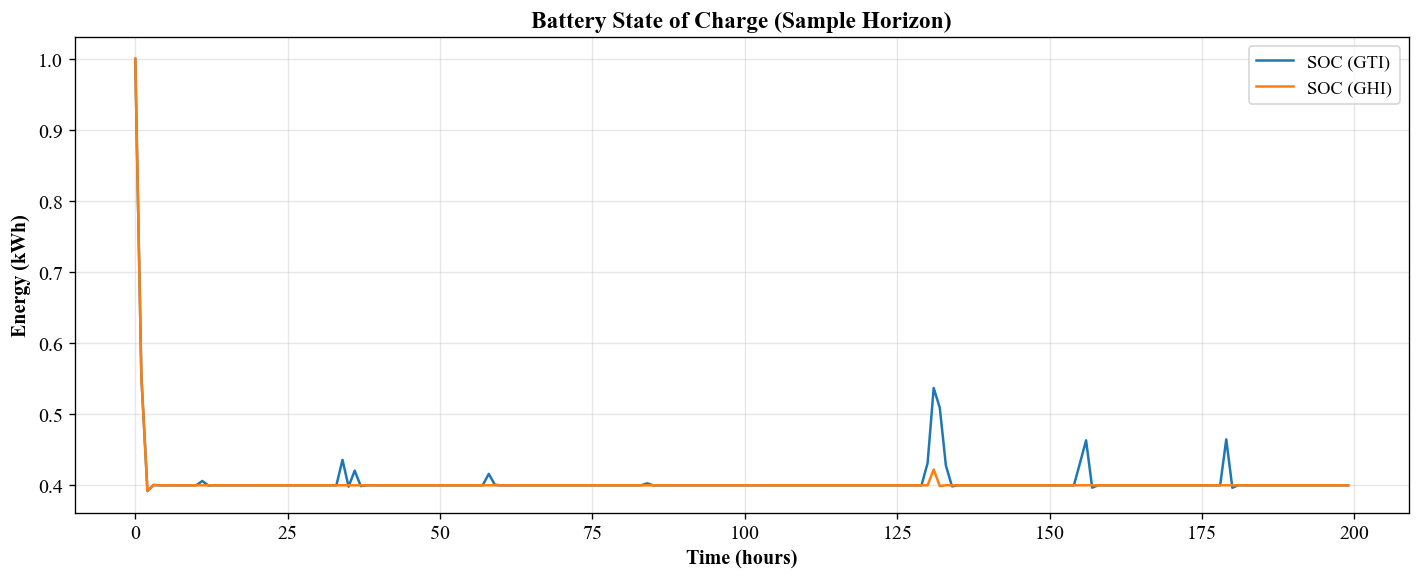

In [58]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Load data ----------------
pv_df = pd.read_csv(os.path.join(OUTPUT_DIR, "pv_results.csv"))
load_df = pd.read_csv(os.path.join(OUTPUT_DIR, "load_results.csv"))

load = load_df["load"].values
pv_gti = pv_df["pv_pred_gti"].values
pv_ghi = pv_df["pv_pred_ghi_corrected"].values

n = len(load)

# ---------------- Battery Parameters ----------------
BAT_CAPACITY = 2.0   # kWh
SOC_MIN = 0.2 * BAT_CAPACITY
SOC_MAX = 0.9 * BAT_CAPACITY

EFF_CH = 0.95
EFF_DIS = 0.95

# ---------------- Simulation Function ----------------
def simulate_battery(pv, load):
    soc = np.zeros(n)
    soc[0] = 0.5 * BAT_CAPACITY
    
    grid_import = np.zeros(n)
    grid_export = np.zeros(n)
    
    charge = np.zeros(n)
    discharge = np.zeros(n)
    
    for t in range(n - 1):
        net = pv[t] - load[t]
        
        if net > 0:
            # Excess PV → charge battery
            available_capacity = SOC_MAX - soc[t]
            charge_power = min(net, available_capacity)
            
            soc[t+1] = soc[t] + EFF_CH * charge_power
            charge[t] = charge_power
            
            # Remaining goes to grid export
            grid_export[t] = net - charge_power
            
        else:
            deficit = -net
            
            available_energy = soc[t] - SOC_MIN
            discharge_power = min(deficit, available_energy)
            
            soc[t+1] = soc[t] - discharge_power / EFF_DIS
            discharge[t] = discharge_power
            
            # Remaining from grid
            grid_import[t] = deficit - discharge_power
    
    return soc, grid_import, grid_export, charge, discharge

# ---------------- Run both scenarios ----------------
soc_gti, grid_imp_gti, grid_exp_gti, ch_gti, dis_gti = simulate_battery(pv_gti, load)
soc_ghi, grid_imp_ghi, grid_exp_ghi, ch_ghi, dis_ghi = simulate_battery(pv_ghi, load)

# ---------------- Aggregate Metrics ----------------
def summarize(grid_imp, grid_exp, charge, discharge):
    return {
        "Grid Import (kWh)": np.sum(grid_imp),
        "Grid Export (kWh)": np.sum(grid_exp),
        "Battery Throughput (kWh)": np.sum(charge + discharge)
    }

metrics_gti = summarize(grid_imp_gti, grid_exp_gti, ch_gti, dis_gti)
metrics_ghi = summarize(grid_imp_ghi, grid_exp_ghi, ch_ghi, dis_ghi)

battery_df = pd.DataFrame({
    "Metric": list(metrics_gti.keys()),
    "GTI-Based": list(metrics_gti.values()),
    "GHI-Based": list(metrics_ghi.values())
})

print("\nBattery Dispatch Metrics:\n")
print(battery_df)

battery_df.to_csv(os.path.join(OUTPUT_DIR, "S-4-Table.csv"), index=False)

# ---------------- Figure S-4-1: SOC Profile ----------------
sample = 200

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(soc_gti[:sample], label="SOC (GTI)", linewidth=1.5)
ax.plot(soc_ghi[:sample], label="SOC (GHI)", linewidth=1.5)

ax.set_title("Battery State of Charge (Sample Horizon)",fontsize=14, fontweight='bold')
ax.set_xlabel("Time (hours)", fontsize=12, fontweight='bold')
ax.set_ylabel("Energy (kWh)",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

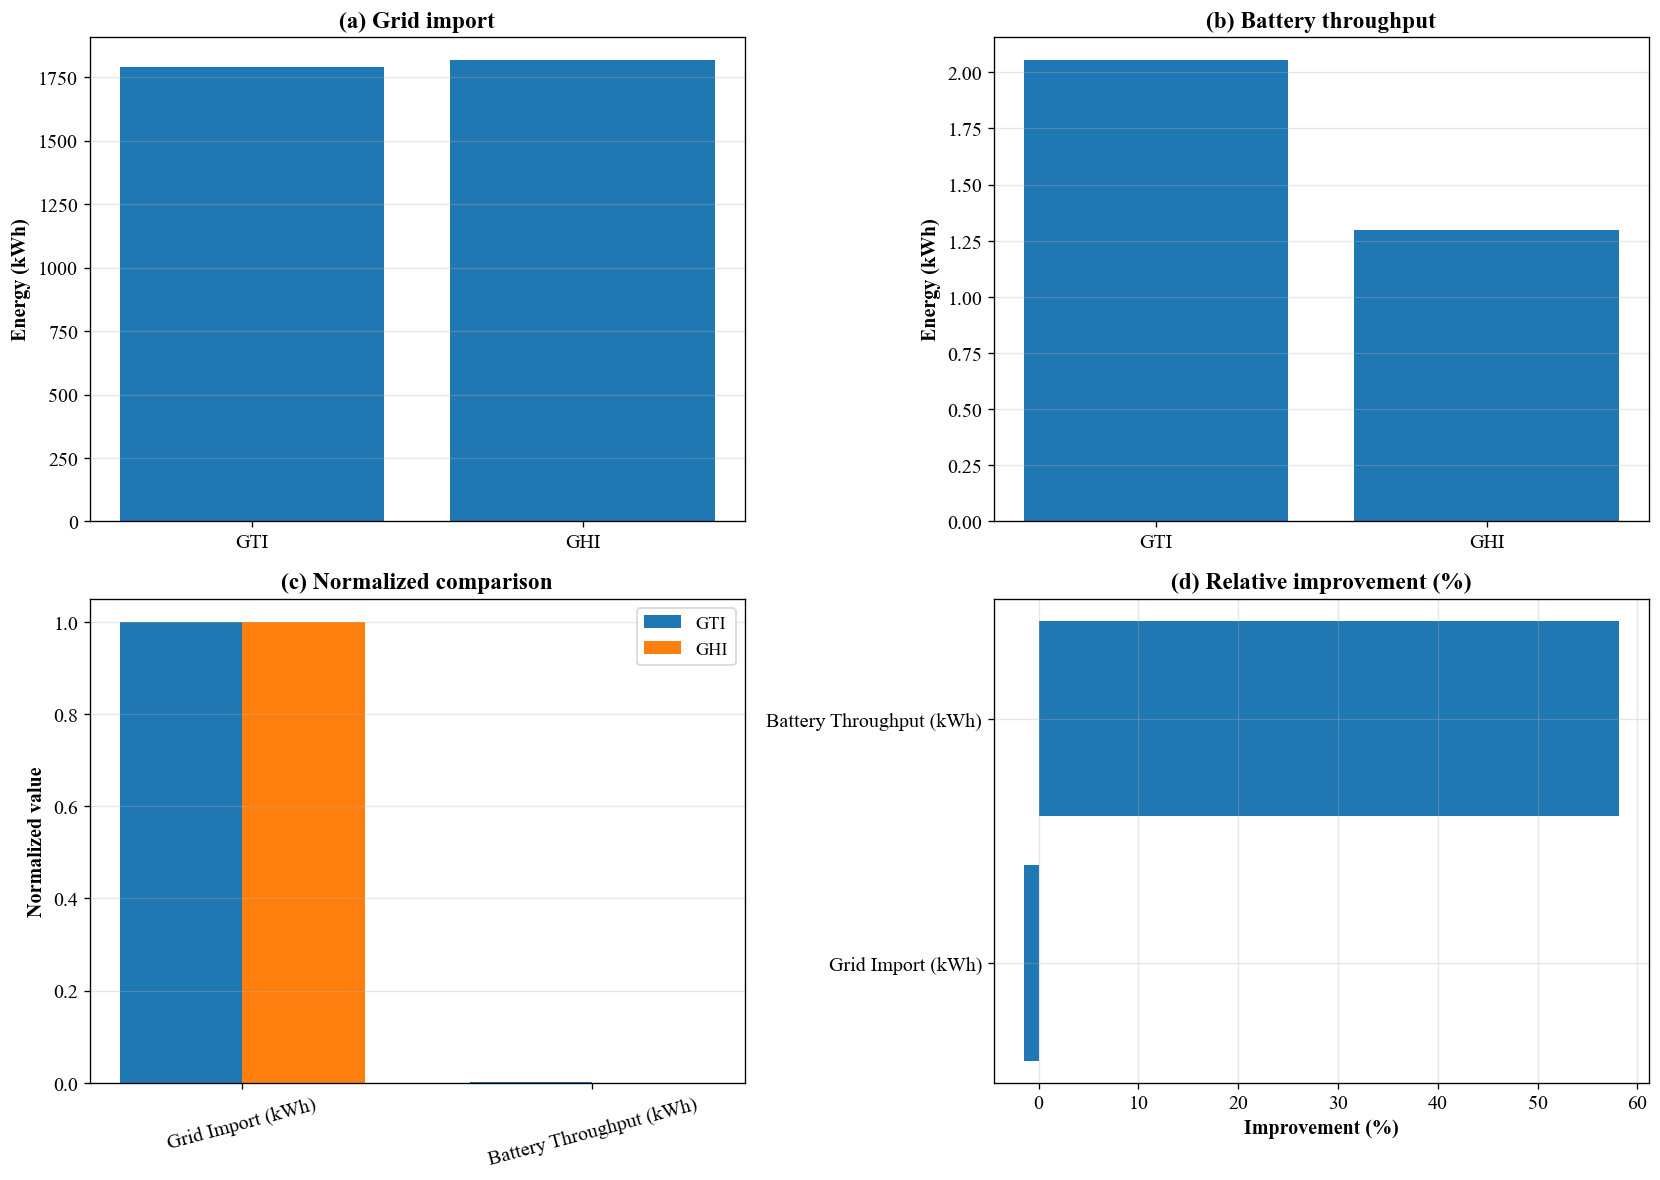

In [61]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Data ----------------
metrics = ["Grid Import (kWh)", "Battery Throughput (kWh)"]

gti_vals = np.array([1789.393462, 2.053693])
ghi_vals = np.array([1816.651316, 1.298552])

# Improvement (%)
improvement = (gti_vals - ghi_vals) / (ghi_vals + 1e-8) * 100

# Normalization (for fair comparison)
gti_norm = gti_vals / np.max(gti_vals)
ghi_norm = ghi_vals / np.max(ghi_vals)

# ---------------- Figure ----------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Grid import
ax = axes[0, 0]
ax.bar(["GTI", "GHI"], [gti_vals[0], ghi_vals[0]])
ax.set_title("(a) Grid import",fontsize=14, fontweight='bold')
ax.set_ylabel("Energy (kWh)",fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# (b) Battery throughput
ax = axes[0, 1]
ax.bar(["GTI", "GHI"], [gti_vals[1], ghi_vals[1]])
ax.set_title("(b) Battery throughput",fontsize=14, fontweight='bold')
ax.set_ylabel("Energy (kWh)",fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# (c) Normalized comparison
ax = axes[1, 0]
x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, gti_norm, width, label="GTI")
ax.bar(x + width/2, ghi_norm, width, label="GHI")

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15)
ax.set_title("(c) Normalized comparison",fontsize=14, fontweight='bold')
ax.set_ylabel("Normalized value",fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# (d) Improvement %
ax = axes[1, 1]
ax.barh(metrics, improvement)
ax.set_title("(d) Relative improvement (%)",fontsize=14, fontweight='bold')
ax.set_xlabel("Improvement (%)",fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
import pandas as pd
import os

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Inputs ----------------
TARIFF = 8.0  # ₹/kWh (typical Indian residential/commercial range)
BATTERY_DEG_COST = 1.5  # ₹/kWh throughput (approximation)

# ---------------- Values ----------------
grid_gti = 1789.393462
grid_ghi = 1816.651316

bat_gti = 2.053693
bat_ghi = 1.298552

# ---------------- Cost Calculation ----------------
def compute_cost(grid, battery):
    grid_cost = grid * TARIFF
    deg_cost = battery * BATTERY_DEG_COST
    total = grid_cost + deg_cost
    return grid_cost, deg_cost, total

gti_costs = compute_cost(grid_gti, bat_gti)
ghi_costs = compute_cost(grid_ghi, bat_ghi)

# ---------------- Create Table ----------------
econ_df = pd.DataFrame({
    "Metric": ["Grid Cost (₹)", "Battery Degradation Cost (₹)", "Total Cost (₹)"],
    "GTI-Based": gti_costs,
    "GHI-Based": ghi_costs
})

# Round for paper
econ_df["GTI-Based"] = econ_df["GTI-Based"].round(2)
econ_df["GHI-Based"] = econ_df["GHI-Based"].round(2)

print("\nEconomic Comparison (INR):\n")
print(econ_df.to_string(index=False))

# Save
econ_df.to_csv(os.path.join(OUTPUT_DIR, "S-5-Table-INR.csv"), index=False)


Economic Comparison (INR):

                      Metric  GTI-Based  GHI-Based
               Grid Cost (₹)   14315.15   14533.21
Battery Degradation Cost (₹)       3.08       1.95
              Total Cost (₹)   14318.23   14535.16


In [30]:
# ---------------- Add Savings ----------------
econ_df["Savings (₹)"] = econ_df["GHI-Based"] - econ_df["GTI-Based"]

# ---------------- Add Improvement (%) ----------------
econ_df["Improvement (%)"] = (
    econ_df["Savings (₹)"] / (econ_df["GHI-Based"] + 1e-8)
) * 100

# Round
econ_df = econ_df.round(2)

print("\nEnhanced Economic Comparison (INR):\n")
print(econ_df.to_string(index=False))

# Save
econ_df.to_csv(os.path.join(OUTPUT_DIR, "S-5-Table-INR-Enhanced.csv"), index=False)

# ---------------- Key Highlight ----------------
total_savings = econ_df.loc[econ_df["Metric"] == "Total Cost (₹)", "Savings (₹)"].values[0]

print(f"\nTotal Economic Benefit (GTI vs GHI): ₹{total_savings:.2f}")


Enhanced Economic Comparison (INR):

                      Metric  GTI-Based  GHI-Based  Savings (₹)  Improvement (%)
               Grid Cost (₹)   14315.15   14533.21       218.06             1.50
Battery Degradation Cost (₹)       3.08       1.95        -1.13           -57.95
              Total Cost (₹)   14318.23   14535.16       216.93             1.49

Total Economic Benefit (GTI vs GHI): ₹216.93



Full-Year Quarterly Savings (₹):

             cost_gti      cost_ghi     savings  savings_pct
quarter                                                     
1        16703.720583  17421.239786  717.519202     4.118646
2        23292.254396  23352.022471   59.768076     0.255944
3        18277.117577  18412.332871  135.215294     0.734374
4        18000.637371  18607.398590  606.761219     3.260860


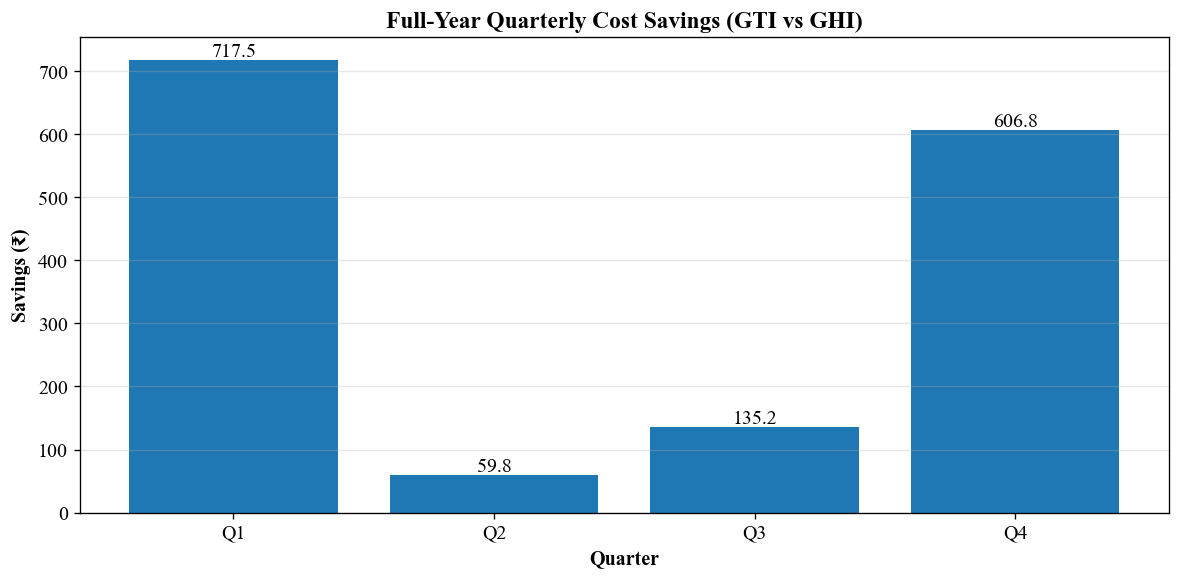

In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = r"/content/drive/MyDrive/figures"

# ---------------- Use FULL dataset ----------------
df_full = df.copy().reset_index(drop=True)

# ---------------- Load (same logic, full length) ----------------
np.random.seed(42)
n = len(df_full)
hours = np.arange(n) % 24

base_load = 0.4
day_peak = 0.6 * np.sin((hours - 12) * np.pi / 24) + 0.6
evening_peak = 0.8 * np.exp(-((hours - 19) ** 2) / 10)
noise = 0.05 * np.random.randn(n)

load_full = base_load + day_peak + evening_peak + noise
load_full = np.clip(load_full, 0.2, None)

# ---------------- PV (FULL) ----------------
G_REF = 1000.0
TEMP_COEFF = 0.004

temp = df_full["air_temp"].values
eta_temp = 1 - TEMP_COEFF * (temp - 25)

# --- GTI (direct)
pv_gti_full = (df_full["gti"].values / G_REF) * eta_temp

# --- GHI → GTI (transposed)
TILT = 20
theta_z = np.radians(df_full["zenith"].values)
beta = np.radians(TILT)

cos_term = np.cos(theta_z - beta)
cos_term = np.clip(cos_term, 0, None)

gti_from_ghi_full = df_full["ghi"].values * cos_term
pv_ghi_full = (gti_from_ghi_full / G_REF) * eta_temp

# ---------------- Cost Model ----------------
TARIFF = 8.0
BATTERY_DEG_COST = 1.5

def compute_cost_series(pv):
    grid_import = np.maximum(load_full - pv, 0)
    battery_proxy = np.abs(np.diff(pv - load_full, prepend=0))
    return grid_import * TARIFF + battery_proxy * BATTERY_DEG_COST

cost_gti = compute_cost_series(pv_gti_full)
cost_ghi = compute_cost_series(pv_ghi_full)

# ---------------- DataFrame ----------------
cost_df = pd.DataFrame({
    "time": df_full["period_end"],
    "cost_gti": cost_gti,
    "cost_ghi": cost_ghi
})

# ---------------- Quarter-wise ----------------
cost_df["quarter"] = cost_df["time"].dt.quarter

quarterly = cost_df.groupby("quarter")[["cost_gti", "cost_ghi"]].sum()
quarterly["savings"] = quarterly["cost_ghi"] - quarterly["cost_gti"]
quarterly["savings_pct"] = (quarterly["savings"] / quarterly["cost_ghi"]) * 100

print("\nFull-Year Quarterly Savings (₹):\n")
print(quarterly)

# ---------------- Figure ----------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14
})

fig, ax = plt.subplots(figsize=(10, 5))

quarters = ["Q1", "Q2", "Q3", "Q4"]
vals = quarterly["savings"].values

ax.bar(quarters, vals)

ax.set_title("Full-Year Quarterly Cost Savings (GTI vs GHI)",fontsize=14, fontweight='bold')
ax.set_xlabel("Quarter",fontsize=12, fontweight='bold')
ax.set_ylabel("Savings (₹)",fontsize=12, fontweight='bold')

for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.1f}", ha='center', va='bottom')

ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.tight_layout()
plt.savefig('Ph.D_2_10.png', dpi=300, bbox_inches='tight')
plt.savefig('Ph.D_2_10.pdf', bbox_inches='tight')
plt.show()

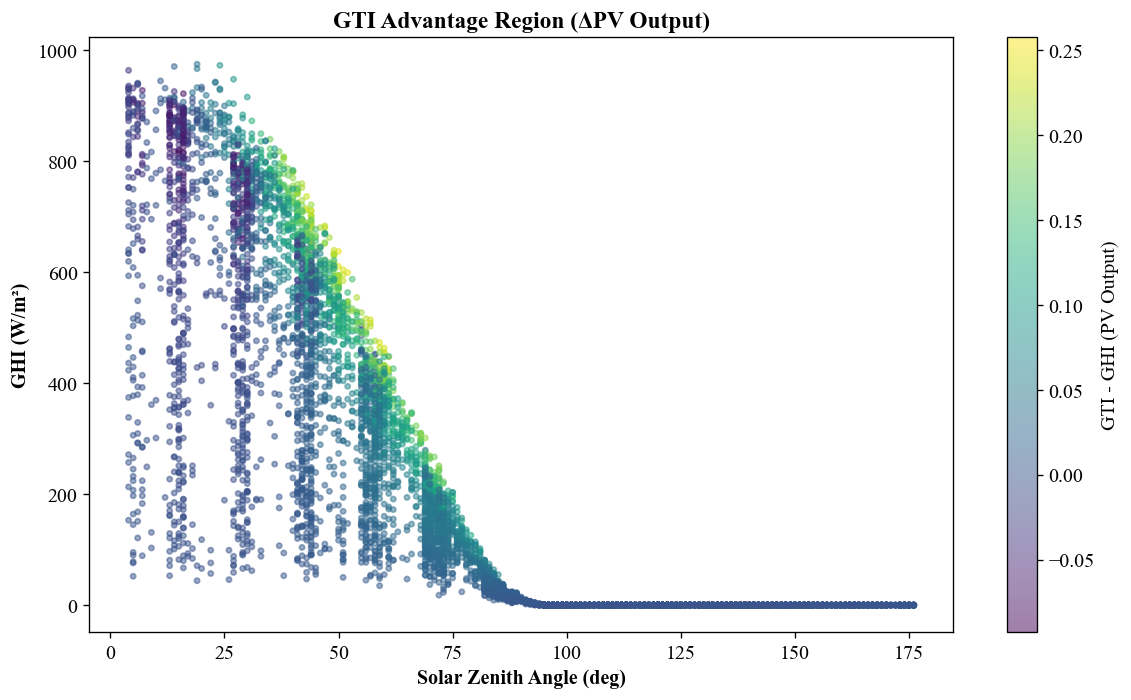

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))

diff = pv_gti_full - pv_ghi_full

sc = ax.scatter(
    df_full["zenith"],
    df_full["ghi"],
    c=diff,
    s=10,
    alpha=0.5
)

ax.set_title("GTI Advantage Region (ΔPV Output)",fontsize=14, fontweight='bold')
ax.set_xlabel("Solar Zenith Angle (deg)",fontsize=12, fontweight='bold')
ax.set_ylabel("GHI (W/m²)",fontsize=12, fontweight='bold')

fig.colorbar(sc, label="GTI - GHI (PV Output)")

plt.tight_layout()
plt.tight_layout()
plt.savefig('Ph.D_2_11.png', dpi=300, bbox_inches='tight')
plt.savefig('Ph.D_2_11.pdf', bbox_inches='tight')
plt.show()

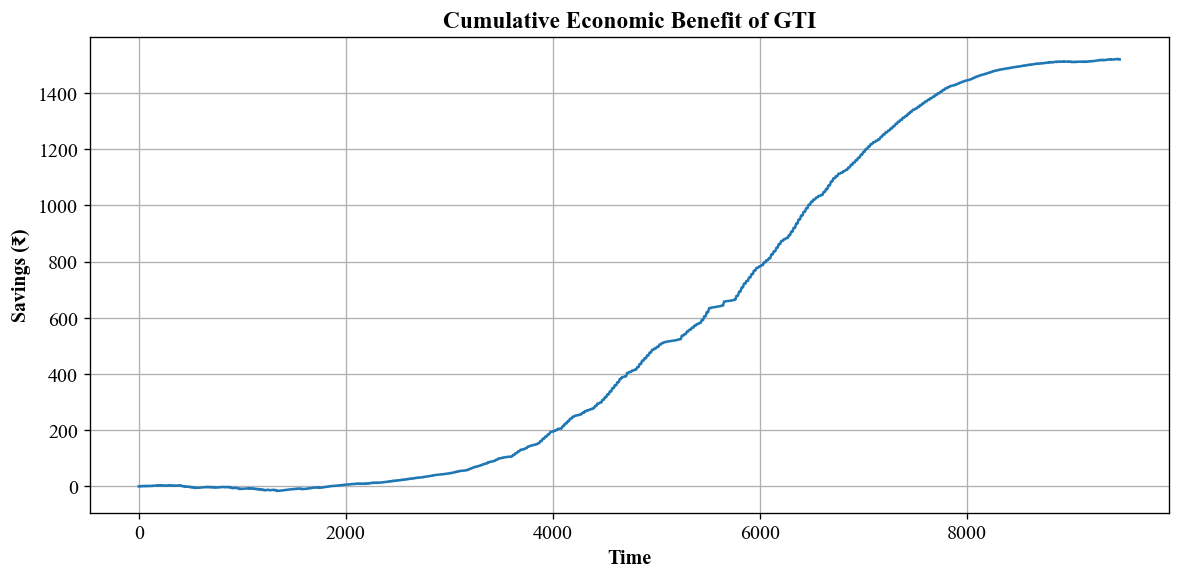

In [74]:
cum_savings = np.cumsum(cost_df["cost_ghi"] - cost_df["cost_gti"])

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cum_savings)

ax.set_title("Cumulative Economic Benefit of GTI",fontsize=14, fontweight='bold')
ax.set_xlabel("Time",fontsize=12, fontweight='bold')
ax.set_ylabel("Savings (₹)",fontsize=12, fontweight='bold')
ax.grid(True)

plt.tight_layout()
plt.tight_layout()
plt.savefig('Ph.D_2_12.png', dpi=300, bbox_inches='tight')
plt.savefig('Ph.D_2_12.pdf', bbox_inches='tight')
plt.show()